In [1]:
file_write = "002_coefs"

In [2]:
n_features_dict = {
    "PLS": 21,
    "Ridge": 19,
    "Lasso": 15,
}

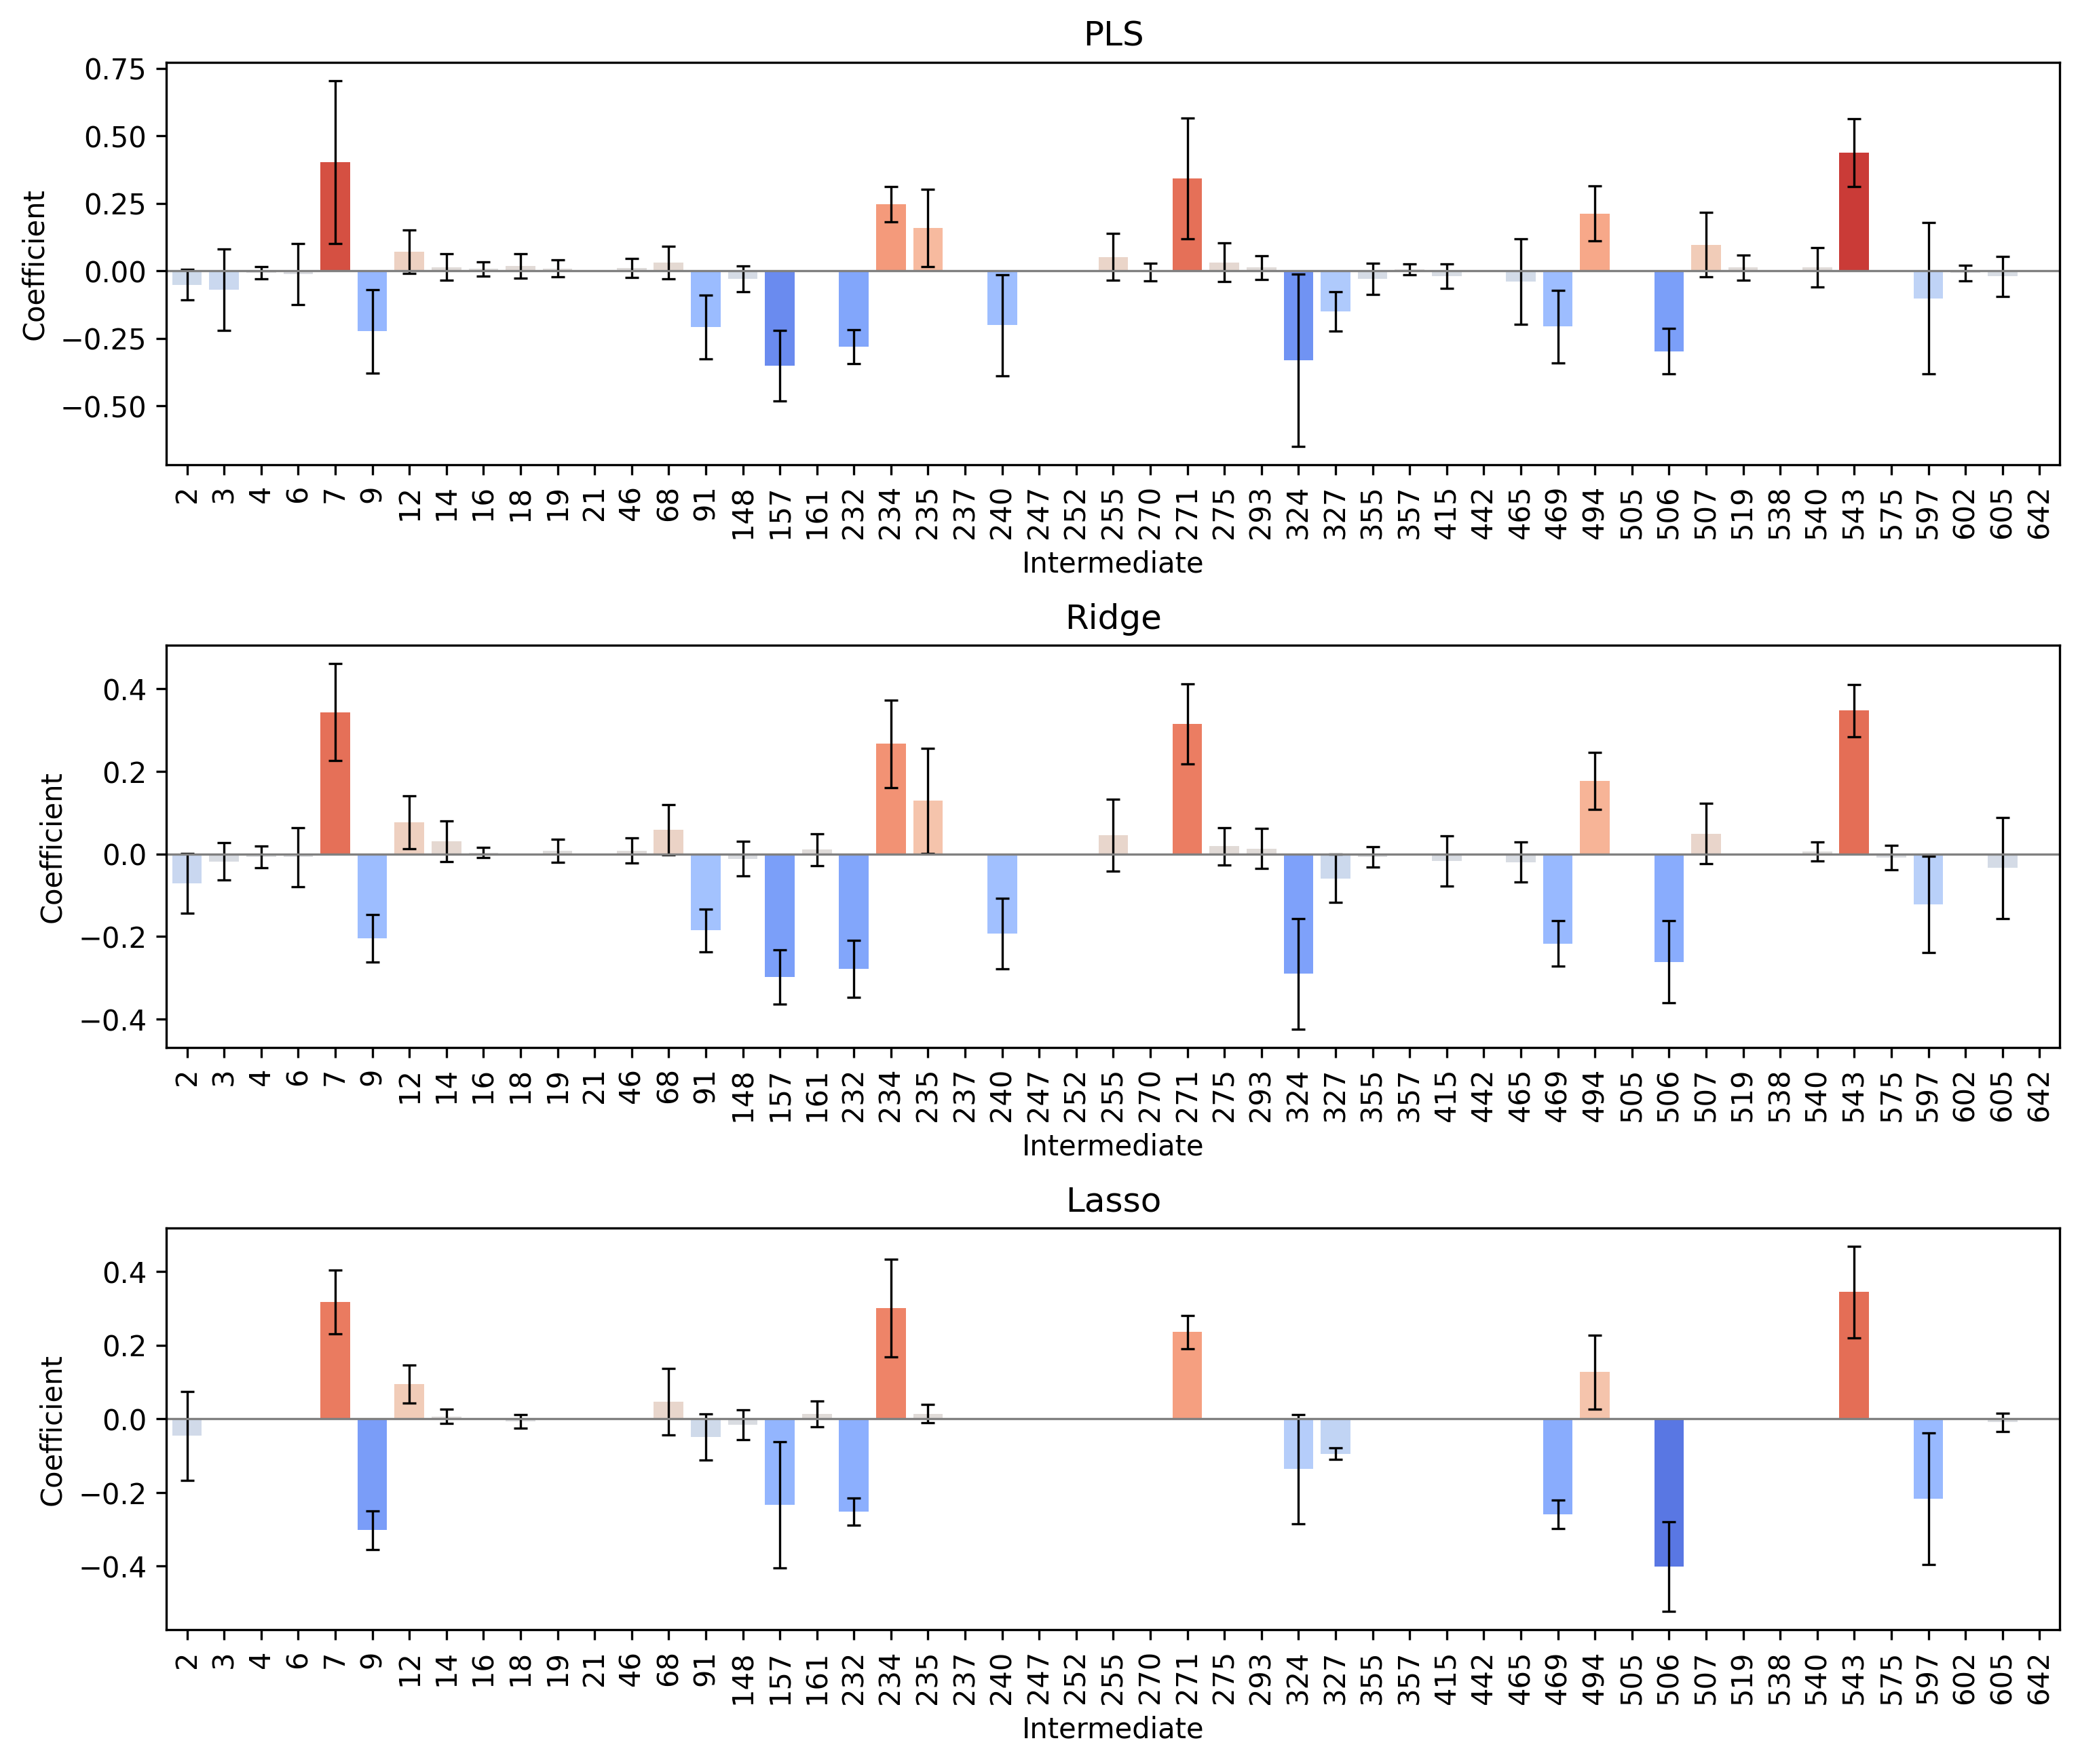

In [3]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=300)
fig.subplots_adjust(hspace=0.45)

for i, (model, n_features) in enumerate(n_features_dict.items()):
    df_coefs = pl.read_parquet(f"../../{model}/fit/001_fit_coefs.parquet")
    df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features)
    columns_feat = [column for column in df_coefs_.columns if "zero" in column]
    
    data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
    data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
    data_std = np.where(data_std == 0.0, np.nan, data_std)
    
    norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
    colors = plt.cm.coolwarm(norm(data_mean))
    error_kw = dict(elinewidth=0.8, capthick=0.8)
    axes[i].bar(
        np.arange(len(data_mean)),
        data_mean,
        yerr=data_std,
        color=colors,
        capsize=2.5,
        error_kw=error_kw
    )
    axes[i].axhline(0, color="gray", linewidth=0.8)
    
    axes[i].set_title(model)
    axes[i].set_xlabel("Intermediate")
    axes[i].set_ylabel("Coefficient")
    axes[i].set_xticks(np.arange(len(data_mean)))
    axes[i].set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
    axes[i].margins(x=0.003)
    
plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()